## Análisis de datos - Clase 3
---

## Taller práctico parte 1 - análisis inicial de un dataset
---


Vamos a realizar una actividad con un dataset con datos del Servicio Meteorológico Nacional Argentino. El dataset contiene estadísticas climáticas normales (período 1991-2020).

Fuente: https://www.smn.gob.ar/descarga-de-datos

Consigna: analizar si hay valores atípicos. ¿Consideran que son legítimos o que son errores?

Resumen de variables:
* estación, provincia, latitud, longitud, altitud, número y NroOACI (estos dos últimos identifican las estaciones)
* mes
* temperatura media, máxima y mínima
* humedad relativa
* velocidad del viento
* nubosidad total (en meteorología, la nubosidad se mide en octas (0, despejado - 8 completamente cubierto), que representan la fracción del cielo cubierta por nubes)
* precipitación
* frecuencia de días con precipitación superior a 0,1 mm.

In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../datasets/smn/smn_historico.csv', na_values=['S/D'])

In [3]:
df.head()

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
0,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Ene,6.7,67.0,3.1,117.5,24.5,28.4,20.8,16.8
1,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Feb,6.0,69.8,3.2,112.3,23.7,27.3,20.2,15.8
2,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Mar,5.9,71.3,3.1,111.8,22.0,25.5,18.8,14.9
3,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Abr,6.6,73.6,3.5,108.3,18.5,22.0,15.3,13.9
4,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,May,5.0,76.4,4.0,83.3,15.2,18.4,12.3,12.9


Filtro el dataset para quedarme solo con la region de Patagonia: NEUQUÉN, RÍO NEGRO, CHUBUT, SANTA CRUZ, TIERRA DEL FUEGO, ANTÁRTIDA

Con .str.strip() elimino espacios al inicio y al final, con lower dejo todo en minuscula 

In [4]:
df["provincia"] = df["provincia"].str.strip().str.lower()

patagonia = [
    "neuquén",
    "río negro",
    "chubut",
    "santa cruz",
    "tierra del fuego",
    "antártida"
]

df_patagonia = df[df["provincia"].isin(patagonia)]

In [12]:
display(df_patagonia.head())
display(df_patagonia.shape)
display(df_patagonia.describe())
df_patagonia.info()

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
204,COMODORO RIVADAVIA AERO,chubut,46.0,87860.0,SAVC,-45.783333,-67.45,Ene,1.6,39.0,4.2,10.7,19.8,26.3,13.5,23.2
205,COMODORO RIVADAVIA AERO,chubut,46.0,87860.0,SAVC,-45.783333,-67.45,Feb,2.3,44.8,4.2,17.3,18.8,25.1,12.8,20.4
206,COMODORO RIVADAVIA AERO,chubut,46.0,87860.0,SAVC,-45.783333,-67.45,Mar,3.0,48.4,4.2,27.7,16.5,22.7,11.0,18.1
207,COMODORO RIVADAVIA AERO,chubut,46.0,87860.0,SAVC,-45.783333,-67.45,Abr,2.6,51.0,4.1,31.8,13.3,18.8,8.5,18.5
208,COMODORO RIVADAVIA AERO,chubut,46.0,87860.0,SAVC,-45.783333,-67.45,May,3.8,57.8,4.5,33.5,10.0,14.6,5.7,18.0


(108, 16)

,altura,numero,LAT_decimal,LON_decimal,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
count,108.000000,108.000000,108.000000,108.000000,84.000000,105.000000,106.000000,84.000000,106.000000,107.000000,108.000000,84.000000
mean,226.444444,87873.000000,-47.344444,-68.892593,3.534524,58.909524,4.160377,21.069048,9.961321,15.714953,4.355556,20.855952
std,246.570395,38.291552,2.856757,2.283288,1.437408,10.538259,0.444368,12.685567,5.118232,5.977802,4.369784,5.356909
min,19.000000,87803.000000,-51.600000,-72.050000,1.400000,39.000000,3.100000,6.900000,0.600000,5.100000,-4.400000,11.700000
25%,46.000000,87852.000000,-49.300000,-70.983333,2.500000,50.700000,3.800000,13.575000,5.675000,11.200000,0.800000,16.900000
50%,80.000000,87880.000000,-47.733333,-69.300000,3.300000,56.900000,4.200000,18.700000,10.200000,16.100000,4.150000,20.400000
75%,358.000000,87904.000000,-45.783333,-67.450000,4.000000,66.400000,4.500000,24.650000,13.775000,20.050000,7.400000,23.925000
max,797.000000,87925.000000,-42.900000,-65.266667,8.800000,79.000000,5.500000,81.100000,21.600000,29.300000,13.700000,36.500000


<class 'pandas.DataFrame'>
Index: 108 entries, 204 to 1079
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   estacion      108 non-null    str    
 1   provincia     108 non-null    str    
 2   altura        108 non-null    float64
 3   numero        108 non-null    float64
 4   NroOACI       108 non-null    str    
 5   LAT_decimal   108 non-null    float64
 6   LON_decimal   108 non-null    float64
 7   mes_txt       108 non-null    str    
 8   prec_sup_1mm  84 non-null     float64
 9   humedad       105 non-null    float64
 10  nubosidad     106 non-null    float64
 11  prec_mm       84 non-null     float64
 12  temp          106 non-null    float64
 13  temp_max      107 non-null    float64
 14  temp_min      108 non-null    float64
 15  viento        84 non-null     float64
dtypes: float64(12), str(4)
memory usage: 14.3 KB


In [24]:
print("Estaciones:" + str(df_patagonia["estacion"].nunique()))
print("Altura media:" + str(df_patagonia["altura"].mean()))
print("Temperatura media:" + str(df_patagonia["temp"].mean()))
print("Desviación estándar de temperatura:" + str(df_patagonia["temp"].std()))
print("Precipitación media:" + str(df_patagonia["prec_mm"].mean()))
mes_mas_calido = df_patagonia.groupby("mes_txt")["temp"].mean().idxmax()
print("Mes más cálido:" + str(mes_mas_calido))
mes_mas_lluvioso = df_patagonia.groupby("mes_txt")["prec_mm"].mean().idxmax()
print("Mes más lluvioso:" + str(mes_mas_lluvioso))
provincia_mas_calida = df_patagonia.groupby("provincia")["temp"].mean().idxmax()
print("Provincia más cálida:" + str(provincia_mas_calida))

Estaciones:9
Altura media:226.44444444444446
Temperatura media:9.961320754716983
Desviación estándar de temperatura:5.118232037664439
Precipitación media:21.06904761904762
Mes más cálido:Ene
Mes más lluvioso:Jun
Provincia más cálida:chubut


In [22]:
print("\n=== Valores nulos por variable ===")
nulos = df_patagonia.isnull().sum()
display(nulos)


=== Valores nulos por variable ===


estacion         0
provincia        0
altura           0
numero           0
NroOACI          0
LAT_decimal      0
LON_decimal      0
mes_txt          0
prec_sup_1mm    24
humedad          3
nubosidad        2
prec_mm         24
temp             2
temp_max         1
temp_min         0
viento          24
dtype: int64

In [25]:
def outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return series[(series < lower) | (series > upper)]

# Outliers
out_temp = outliers_iqr(df_patagonia["temp"])
out_prec = outliers_iqr(df_patagonia["prec_mm"])

print("Outliers temperatura:", len(out_temp))
print("Outliers precipitación:", len(out_prec))

Outliers temperatura: 0
Outliers precipitación: 4


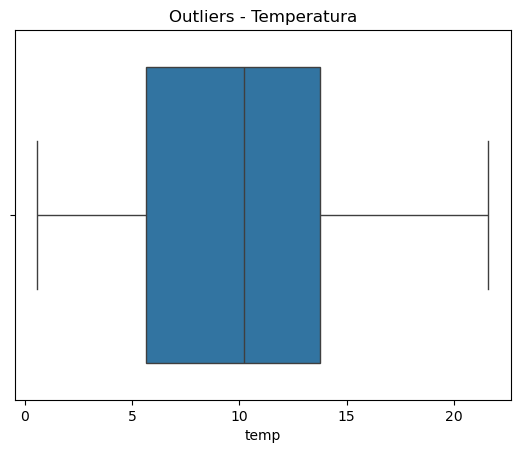

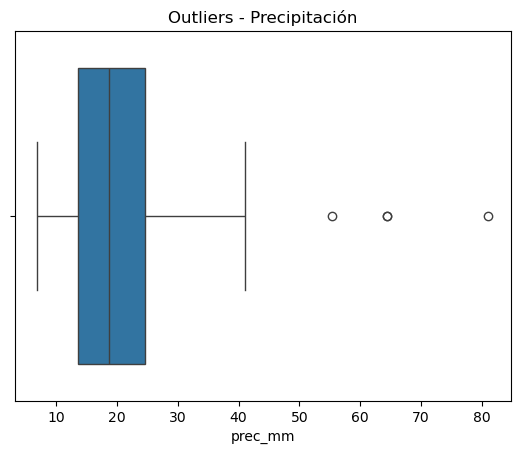

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_patagonia["temp"])
plt.title("Outliers - Temperatura")
plt.show()

sns.boxplot(x=df_patagonia["prec_mm"])
plt.title("Outliers - Precipitación")
plt.show()

In [27]:
import numpy as np

z_scores = (df_patagonia["temp"] - df_patagonia["temp"].mean()) / df_patagonia["temp"].std()

outliers_z = df_patagonia[np.abs(z_scores) > 3]

print(len(outliers_z))

0


In [28]:
df_chubut = df_patagonia[df_patagonia["provincia"] == "chubut"]

df_chubut[["temp", "prec_mm", "humedad", "nubosidad", "viento"]].describe()

,temp,prec_mm,humedad,nubosidad,viento
count,36.000000,36.000000,36.000000,36.000000,36.000000
mean,11.838889,26.355556,54.638889,3.980556,17.752778
std,5.476458,16.323488,9.992462,0.441309,3.094002
min,1.700000,10.700000,39.000000,3.100000,12.500000
25%,7.825000,16.650000,47.475000,3.675000,15.025000
50%,11.850000,21.350000,53.600000,3.950000,18.050000
75%,16.050000,28.875000,60.200000,4.400000,19.925000
max,21.600000,81.100000,75.400000,4.600000,24.400000
